In [8]:
import json
# Load and display the first JSONL file
with open('C:/Users/simon/Desktop/utbm/Bucarest Cours/ATAI/RL/crafter/Results_save/double DQN catregorized plus parameter/stats.jsonl', 'r') as file:
    training_metrics = [json.loads(line) for line in file]
    # Display the keys of the first JSON object in the list
    print("Training Metrics Keys:")
    for key in training_metrics[0].keys():
        print(key)



Training Metrics Keys:
length
reward
achievement_collect_coal
achievement_collect_diamond
achievement_collect_drink
achievement_collect_iron
achievement_collect_sapling
achievement_collect_stone
achievement_collect_wood
achievement_defeat_skeleton
achievement_defeat_zombie
achievement_eat_cow
achievement_eat_plant
achievement_make_iron_pickaxe
achievement_make_iron_sword
achievement_make_stone_pickaxe
achievement_make_stone_sword
achievement_make_wood_pickaxe
achievement_make_wood_sword
achievement_place_furnace
achievement_place_plant
achievement_place_stone
achievement_place_table
achievement_wake_up


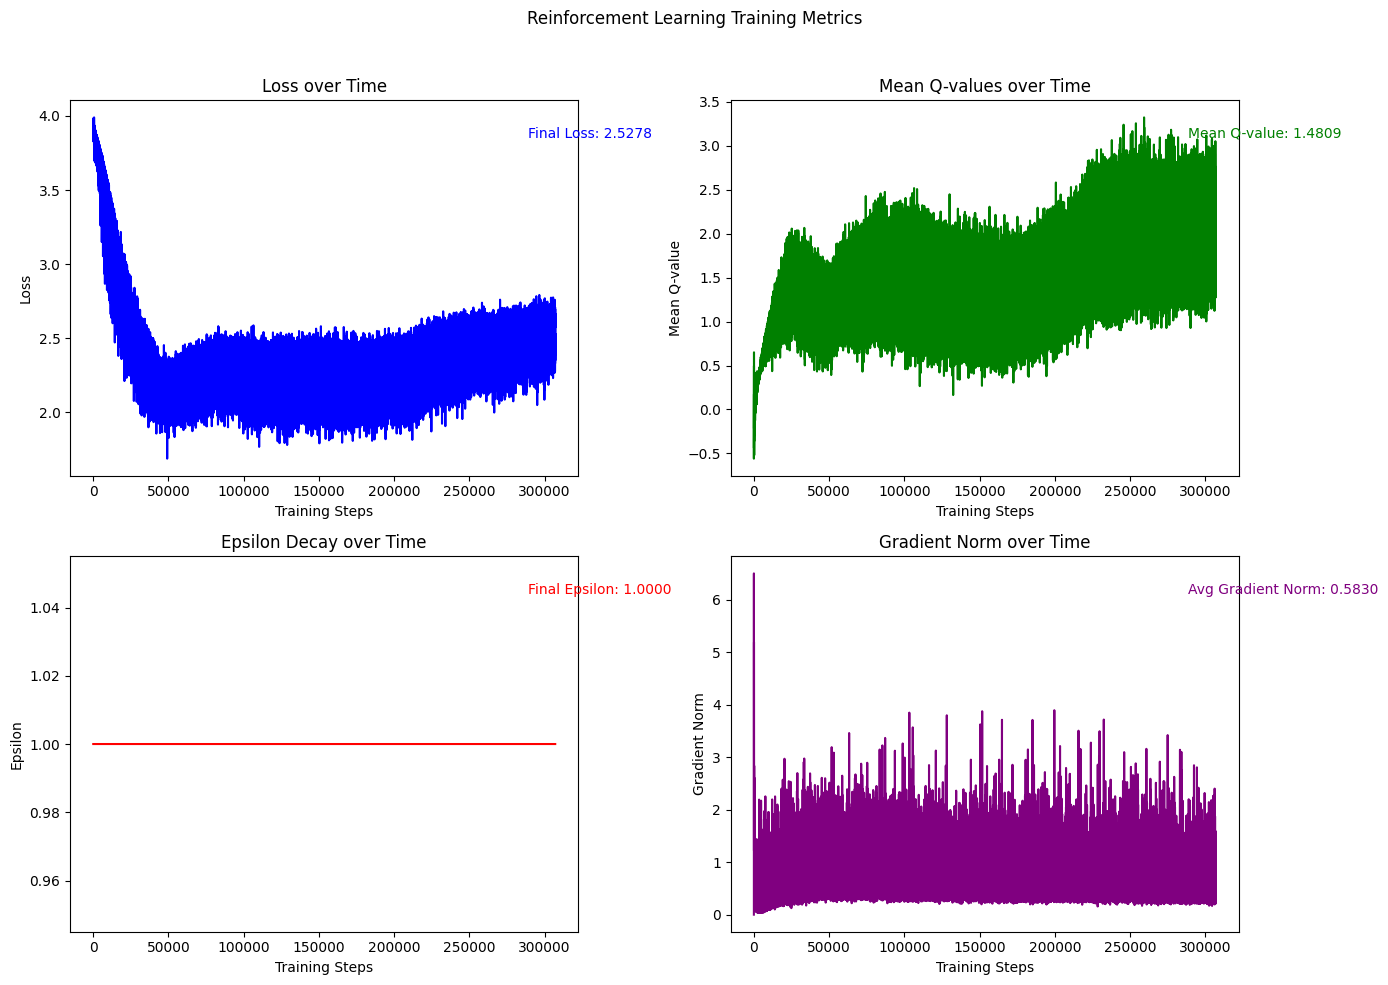

In [12]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Charger le fichier JSON
file_path = 'C:/Users/simon/Desktop/utbm/Bucarest Cours/ATAI/RL/crafter/logdir/random_agent/0/training_metrics.json'
with open(file_path, 'r') as file:
    training_metrics = json.load(file)

# Extraction des valeurs (deuxième élément de chaque sous-liste)
def extract_values(data):
    """Extrait le deuxième élément (valeur) de chaque sous-liste [tour, valeur]."""
    return [entry[1] for entry in data if isinstance(entry, list) and len(entry) == 2]

# Appliquer l'extraction pour chaque métrique
loss = extract_values(training_metrics.get("loss", []))
q_values_mean = extract_values(training_metrics.get("q_values_mean", []))
epsilon = extract_values(training_metrics.get("epsilon", []))
gradient_norm = extract_values(training_metrics.get("gradient_norm", []))

# Vérification que les données sont bien chargées et non vides
if not loss or not q_values_mean or not epsilon or not gradient_norm:
    print("Certaines des métriques sont manquantes ou vides.")
else:
    # Création des graphiques
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Reinforcement Learning Training Metrics")

    # Loss plot
    axs[0, 0].plot(loss, color='blue')
    axs[0, 0].set_title("Loss over Time")
    axs[0, 0].set_xlabel("Training Steps")
    axs[0, 0].set_ylabel("Loss")
    axs[0, 0].annotate(f"Final Loss: {loss[-1]:.4f}", xy=(0.9, 0.9), xycoords='axes fraction', color="blue")

    # Q-values mean plot
    axs[0, 1].plot(q_values_mean, color='green')
    axs[0, 1].set_title("Mean Q-values over Time")
    axs[0, 1].set_xlabel("Training Steps")
    axs[0, 1].set_ylabel("Mean Q-value")
    axs[0, 1].annotate(f"Mean Q-value: {np.mean(q_values_mean):.4f}", xy=(0.9, 0.9), xycoords='axes fraction', color="green")

    # Epsilon decay plot
    axs[1, 0].plot(epsilon, color='red')
    axs[1, 0].set_title("Epsilon Decay over Time")
    axs[1, 0].set_xlabel("Training Steps")
    axs[1, 0].set_ylabel("Epsilon")
    axs[1, 0].annotate(f"Final Epsilon: {epsilon[-1]:.4f}", xy=(0.9, 0.9), xycoords='axes fraction', color="red")

    # Gradient norm plot
    axs[1, 1].plot(gradient_norm, color='purple')
    axs[1, 1].set_title("Gradient Norm over Time")
    axs[1, 1].set_xlabel("Training Steps")
    axs[1, 1].set_ylabel("Gradient Norm")
    axs[1, 1].annotate(f"Avg Gradient Norm: {np.mean(gradient_norm):.4f}", xy=(0.9, 0.9), xycoords='axes fraction', color="purple")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
